# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

**a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS)**

The primary difference between the two is that PCR is an unsupervised method (doesn't include output data) and PLS is a supervised method (includes output data). PCR works by running PCA on the predictors `X` to find the directions of maximum variance, meaning the response `Y` is not used to determine the principle component directions. In contrast, PLS attempts to find principle component directions that explain both the predictor *and* response variables.


**b. Why might PCR fail to find directions that are useful for predicting the response `Y`?** 

Because PCR uses PCA, it finds directions that capture the maximum variance. However, directions that capture variance may not necessarily have any correlation with the response `Y`, and information that best predicts the response `Y` may not necessarily have the highest variance.

**c. In PLS, how is the first direction `Z₁` computed?** 

`Z₁` is computed by the function $Z_1 = \sum_{j=1}^{p} \phi_{j1} X_j $, where $p$ is the number of predictors and $\phi_{j1}$ is the coefficient from the linear regression of $Y$ onto $X_j$ (which is proportional to the correlation between $Y$ and $X_j$). 

*(This is contrast to PCR, where $\phi_{1}$ is instead the eigenvector corresponding to the largest eigenvalue of the X covariance matrix)*

**d. What are some similarities and differences between PLS and penalized regression?** 

**Similarities:** Both PLS and penalized regression (like Lasso or Ridge) are supervised learning methods and are useful for high-dimensional data (because they aim to reduce the number of dimensions).

**Differences:** PLS reduces dimensionality by extracting component variables, whereas penalized regression directly shrinks regression coefficients (according to what variables are the best/worst predictors). 

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component. 

In [10]:
# YOUR CODE HERE
# Import libraries/dependencies
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# recreate tutorial dataset
rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2
#      train/reporting partition
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

# Fit PLS Regression with 1 component
pls = PLSRegression(n_components=1)
pls.fit(X_train, y_train)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",1
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True
Name,Type,Value
"coef_ coef_: ndarray of shape (n_target, n_features)The coefficients of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`.","ndarray[float64](1, 2)","[[ 0.69,-0.66]]"
"intercept_ intercept_: ndarray of shape (n_targets,)The intercepts of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`... versionadded:: 1.1","ndarray[float64](1,)",[0.06]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,2
"n_iter_ n_iter_: list of shape (n_components,)Number of iterations of the power method, for eachcomponent.",list,[1]
"x_loadings_ x_loadings_: ndarray of shape (n_features, n_components)The loadings of `X`.","ndarray[float64](2, 1)","[[-0.17], [ 1.19]]"


### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

YOUR TEXT HERE

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

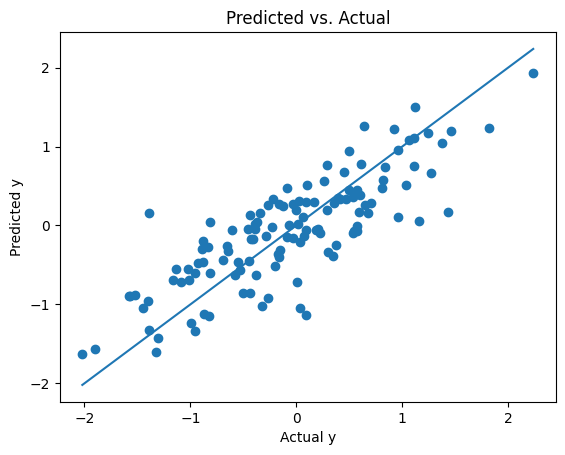

In [11]:
# YOUR CODE HERE

# Change number of components to 2
pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)

# Predict y values on the reporting set
y_pred = pls.predict(X_test).ravel()

# Plot predicted vs. actual
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Predicted vs. Actual")
plt.show()

In [12]:
# Find R^2 and MSE

r2 = pls.score(X_test, y_test)
mse = np.mean((y_test - y_pred) ** 2)

print('R2:', r2)
print('MSE:', mse)

R2: 0.6732047416473494
MSE: 0.21659109767291346


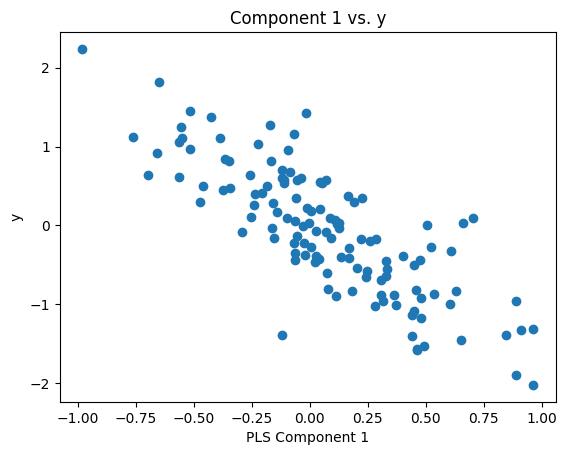

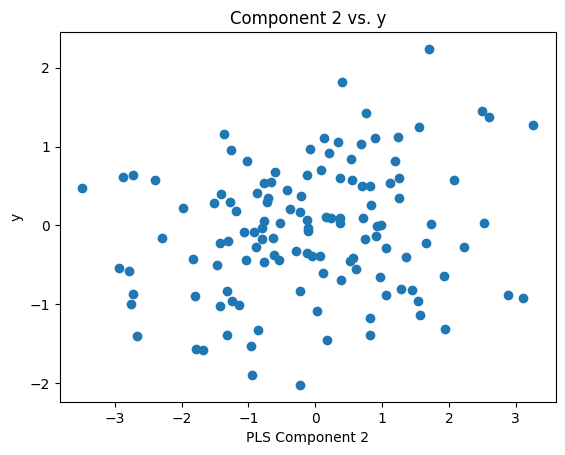

In [13]:
# Get components for the reporting set
X_components = pls.transform(X_test)

# Component 1
component_1 = X_components[:, 0]
corr_1 = np.corrcoef(component_1, y_test)[0, 1]

plt.scatter(component_1, y_test)
plt.xlabel("PLS Component 1")
plt.ylabel("y")
plt.title("Component 1 vs. y")
plt.show()

# Component 2
component_2 = X_components[:, 1]
corr_2 = np.corrcoef(component_2, y_test)[0, 1]

plt.scatter(component_2, y_test)
plt.xlabel("PLS Component 2")
plt.ylabel("y")
plt.title("Component 2 vs. y")
plt.show()

### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
- Did increasing the number of components improve performance?
- What makes PLS different from PCA?

YOUR TEXT HERE

## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

In [11]:
# use the correct imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# load the dataset
data = pd.read_csv('lab01_data.csv')
print(data.shape)
print(data.columns)

# set random state, same as above 
rng = np.random.RandomState(0)

# separate the variables
X = data.iloc[:,:1107]
y = data['permeability']

# train/report split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rng)

(165, 1108)
Index(['fingerprint1', 'fingerprint2', 'fingerprint3', 'fingerprint4',
       'fingerprint5', 'fingerprint6', 'fingerprint7', 'fingerprint8',
       'fingerprint9', 'fingerprint10',
       ...
       'fingerprint1099', 'fingerprint1100', 'fingerprint1101',
       'fingerprint1102', 'fingerprint1103', 'fingerprint1104',
       'fingerprint1105', 'fingerprint1106', 'fingerprint1107',
       'permeability'],
      dtype='str', length=1108)


### b. Create a pipeline.

Create a pipeline that includes the following: 

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

In [12]:
# imports
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

pls_pipeline = Pipeline([
    ('variance_threshold', VarianceThreshold(threshold=0.01)), # remove near-constant binary features by setting a threshold
    ('scaler', StandardScaler()), #scale using StandardScaler() since using pls 
    ('pls', PLSRegression(n_components=2))  # use pls 
])

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.

In [ ]:
# imports
from sklearn.model_selection import GridSearchCV

# use CV
param_grid = {'pls__n_components': range(1, 20)}
grid_search = GridSearchCV(
    pls_pipeline,
    param_grid,
    cv=5,
    scoring='r2'
)
grid_search.fit(X_train, y_train)
best_pls_pipeline = grid_search.best_estimator_

# report the number of predictors remaining after the variance threshold step
vt_step = best_pls_pipeline.named_steps['variance_threshold']
number_remaining = vt_step.get_support().sum()
print(f"Predictors remaining after variance thresholding: {number_remaining} out of {X_train.shape[1]}")

# report the selected number of PLS components
best_n_components = grid_search.best_params_['pls__n_components']
print(f"Selected number of PLS components: {best_n_components}")

# R^2 value on training set
best_cv_r2 = grid_search.best_score_
print(f"Cross-validated R^2: {best_cv_r2:.4f}")

Predictors remaining after variance thresholding: 676 out of 1107
Selected number of PLS components: 2
Cross-validated R²: 0.3088


### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

In [14]:
# import r2_score
from sklearn.metrics import r2_score

# predict permeability on the reporting set 
y_pred = best_pls_pipeline.predict(X_test)

#report the reporting set R^2
test_r2 = r2_score(y_test, y_pred)
print(f"Reporting set R^2: {test_r2:.4f}")

Reporting set R^2: 0.3319


### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.

In [17]:
# imports
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso

# new pipeline with Ridge
pcr_pipeline_ridge = Pipeline([
    ('variance_threshold', VarianceThreshold(threshold=0.01)),
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('regressor', Ridge()) 
])

#optimize using CV
param_grid_ridge = {
    'pca__n_components': range(1, 20),
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
grid_ridge = GridSearchCV(pcr_pipeline_ridge, param_grid_ridge, cv=5, scoring='r2')

# fit and predict 
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
test_r2_ridge = r2_score(y_test, y_pred_ridge)

# print results of CV
print(f"Ridge: n_components: {grid_ridge.best_params_['pca__n_components']}")
print(f"Ridge: alpha: {grid_ridge.best_params_['regressor__alpha']}")
print(f"Ridge: CV R^2: {grid_ridge.best_score_:.4f}")
print(f"Ridge: Test R^2: {test_r2_ridge:.4f}")

Ridge: n_components: 9
Ridge: alpha: 100
Ridge: CV R^2: 0.3392
Ridge: Test R^2: 0.3910


In [18]:
# pipeline with lasso
pcr_pipeline_lasso = Pipeline([
    ('variance_threshold', VarianceThreshold(threshold=0.01)),
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('regressor', Lasso(max_iter=10000))
])

#optimize using cv
param_grid_lasso = {
    'pca__n_components': range(1, 20),
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
grid_lasso = GridSearchCV(pcr_pipeline_lasso, param_grid_lasso, cv=5, scoring='r2')

#fit and predict 
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)
test_r2_lasso = r2_score(y_test, y_pred_lasso)

# print results of cv
print(f"Lasso n_components: {grid_lasso.best_params_['pca__n_components']}")
print(f"Lasso alpha: {grid_lasso.best_params_['regressor__alpha']}")
print(f"Lasso CV R^2: {grid_lasso.best_score_:.4f}")
print(f"Lasso Test R^2: {test_r2_lasso:.4f}")

Lasso n_components: 9
Lasso alpha: 0.01
Lasso CV R^2: 0.3388
Lasso Test R^2: 0.3863


### f. Reflect

Discuss:
- Which model performed best?

The model that performed the best was the Ridge model. The test R^2 value was 0.3868. This was higher than the lasso test R^2 value of 0.3861 and the PLS model test R^2 value of 0.3319. 

- Would you trust any of your models enough to replace the permeability lab assay?

No, not as a full replacement because the R^2 values are very low. 


- What would be the trade-offs of doing so?

The trade-offs in replacing the permeability lab assay with my model is that it would be cheaper and faster but there woudl be a greater risk in getting false positives and false negatives. The model is instant and free but only around 35% predictive which is not good. 

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE